In [48]:
import itertools
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats
from procompa import get_project_root

%config InlineBackend.figure_format = "retina"

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"
pipeline_dir = data_dir / "Pipeline"

RUN_FOLDERS = {
    "ranking": "10_all_CP_complexes",
    "pae": "18_CP_model_based_on_pae",
    "trimmed_safeguard": "20_CP_pae_plddt_trimmed_interface_safeguard",
    "trimmed": "19_CP_pae_plddt_trimmed",
}
complextab_path = data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv"

MIN_PROTEINS = 3                # complexes need at least this many UniProt proteins
INCLUDE_TRUE_CANDIDATE = True   # True = also let the "true" CombFold run compete
ONLY_NON_TRIVIAL_STOICH = False   # True = only complexes where at least one protein has a copy number != 1 in the TRUE stoichiometr

PRED_SOURCES = ["pred_1", "pred_2", "pred_3"]
SOURCES = PRED_SOURCES + (["true"] if INCLUDE_TRUE_CANDIDATE else [])
SOURCE_COLORS = {"pred_1": "#8fb0d1", "pred_2": "#e8c58d", "pred_3": "#a9cfa4", "true": "#d0d0d0"}

# a stoichiometry entry must look like 'P12345:2' (6 or 10 char UniProt accession)
UNIPROT_ENTRY = r"^[A-Z][0-9][A-Z0-9]{3}[0-9]([A-Z][A-Z0-9]{2}[0-9])?:\d+$"


In [49]:
def protein_entries(stoich_text: pl.Expr) -> pl.Expr:
    """'B:1,CHEBI:123:1,URS00x_559292:1,CPX-1:1,EBI-1:1,A:2' -> sorted list ['A:2', 'B:1'] (non-protein entries dropped)"""
    return (
        stoich_text.str.split(",")
        .list.eval(pl.element().filter(
            ~pl.element().str.starts_with("CHEBI:")
            & ~pl.element().str.starts_with("URS")
            & ~pl.element().str.starts_with("CPX-")
            & ~pl.element().str.starts_with("EBI-")
        ))
        .list.sort()
    )
    

def predicted_stoich_text(column: str) -> pl.Expr:
    """pred cell '{"P1":1,"P2":2},{"rank":1,...}' -> 'P1:1,P2:2'"""
    return pl.col(column).str.extract(r"^\{([^}]*)\}").str.replace_all('"', "")


def best_assembly_confidence(column: str) -> pl.Expr:
    """'{0: 65.5, 1: 68.0}' -> 68.0 (best assembly of this candidate); '{}' -> null"""
    return (pl.col(column).str.replace_all(r"\d+:", "")              # drop the dict keys
            .str.extract_all(r"-?\d+(?:\.\d+)?")
            .list.eval(pl.element().cast(pl.Float64)).list.max())

def read_combfold_results(folder: str) -> pl.DataFrame:
    path = pipeline_dir / folder / f"all_pdb_present_{folder}_pool_pipeline_complexes_combfold_results.csv"
    assert path.exists(), f"missing results file: {path}"
    combfold_results = pl.read_csv(path)
    assert combfold_results["complex_ac"].is_unique().all(), f"{folder}: more than one row per complex"
    return combfold_results


def assert_valid_uniprot_entries(table: pl.DataFrame, entries_column: str, what: str):
    invalid = table.filter(~pl.col(entries_column).list.eval(pl.element().str.contains(UNIPROT_ENTRY)).list.all())
    assert invalid.height == 0, f"{what}: {invalid.height} rows with non-UniProt entries, e.g. {invalid[entries_column].head(3).to_list()}"

In [50]:
# %%
# ---------------- true stoichiometry, UniProt proteins only ----------------
complextab_raw = pl.read_csv(complextab_path, separator="\t")
true_stoich_per_complex = (
    complextab_raw
    .rename({"#Complex ac": "complex_ac", complextab_raw.columns[4]: "identifiers"})
    .select(
        "complex_ac",
        # '[A,B]:1' = either paralog fills the slot, cannot be compared to a prediction
        has_paralog_group=pl.col("identifiers").str.contains(r"\["),
        # 'P12345-PRO_0000001:1' = processed chain, predictions use the plain accession
        has_chain_id=pl.col("identifiers").str.contains(r"-PRO_"),
        true_entries=protein_entries(pl.col("identifiers").str.replace_all(r"\((\d+)\)", ":$1").str.replace_all(r"\|", ",")),
    )
    .with_columns(
        n_proteins=pl.col("true_entries").list.len(),
        # "(0)" = unknown copy number; only judged on the proteins, CHEBI/RNA/complex entries are ignored
        stoich_is_known=~pl.col("true_entries").list.eval(pl.element().str.ends_with(":0")).list.any(),
        true_stoich=pl.col("true_entries").list.join(","),
    )
)
assert true_stoich_per_complex["complex_ac"].is_unique().all(), "duplicate complex_ac in the ComplexTab"

# complexes that cannot be compared as strings are dropped (printed, not silent)
known_stoich_complexes = true_stoich_per_complex.filter(pl.col("stoich_is_known"))
for flag, meaning in [("has_paralog_group", "paralog groups '[A,B]'"), ("has_chain_id", "chain ids '-PRO_'")]:
    flagged = known_stoich_complexes.filter(pl.col(flag))["complex_ac"].to_list()
    print(f"{len(flagged)} complexes with known stoichiometry have {meaning} (dropped): {flagged}")

clean_known_complexes = known_stoich_complexes.filter(~pl.col("has_paralog_group") & ~pl.col("has_chain_id"))
not_uniprot_entries = (
    clean_known_complexes.select("complex_ac", entry=pl.col("true_entries"))
    .explode("entry")
    .filter(~pl.col("entry").str.contains(UNIPROT_ENTRY))
)
print(f"{not_uniprot_entries.height} non-UniProt entries left")
print(not_uniprot_entries.head(20))
assert_valid_uniprot_entries(clean_known_complexes, "true_entries", "ComplexTab (known stoichiometry, comparable)")

2 complexes with known stoichiometry have paralog groups '[A,B]' (dropped): ['CPX-1599', 'CPX-1601']
2 complexes with known stoichiometry have chain ids '-PRO_' (dropped): ['CPX-1721', 'CPX-1722']
0 non-UniProt entries left
shape: (0, 2)
┌────────────┬───────┐
│ complex_ac ┆ entry │
│ ---        ┆ ---   │
│ str        ┆ str   │
╞════════════╪═══════╡
└────────────┴───────┘


In [51]:
results_per_run = {run: read_combfold_results(folder) for run, folder in RUN_FOLDERS.items()}
for run, run_results in results_per_run.items():
    print(f"{run}: {run_results.height} complexes")


def build_candidates(run: str) -> pl.DataFrame:
    """One row per (complex, source): stoichiometry (UniProt only) + best CombFold confidence (null = no assembly)"""
    run_results = results_per_run[run]
    parts = [
        run_results.select(
            "complex_ac",
            source=pl.lit(f"pred_{rank}"),
            stoich=protein_entries(predicted_stoich_text(f"pred_{rank}")).list.join(","),
            cf_confidence=best_assembly_confidence(f"CF_{rank}_confidence"),
        )
        for rank in (1, 2, 3)
    ]
    if INCLUDE_TRUE_CANDIDATE:
        # the true stoichiometry was only run by the pipeline when no prediction matched it
        parts.append(
            run_results.select(
                "complex_ac",
                source=pl.lit("true"),
                cf_confidence=pl.when(pl.col("correct_pred_rank").cast(pl.String) == "none")
                                .then(best_assembly_confidence("CF_true_confidence")),
            )
            .join(true_stoich_per_complex.select("complex_ac", stoich="true_stoich"), on="complex_ac", how="left")
            .select("complex_ac", "source", "stoich", "cf_confidence")
        )
    return pl.concat(parts).with_columns(run=pl.lit(run))


candidates_per_run = {run: build_candidates(run) for run in RUN_FOLDERS}

ranking: 613 complexes
pae: 466 complexes
trimmed_safeguard: 466 complexes
trimmed: 466 complexes


In [52]:
# ---------------- which complexes are kept (height after every step) ----------------
funnel_steps = []

complexes_per_run = [set(run_results["complex_ac"]) for run_results in results_per_run.values()]
funnel_steps.append(("complexes in any run csv", len(set.union(*complexes_per_run))))

in_all_csvs = set.intersection(*complexes_per_run)
funnel_steps.append(("in all 4 run csvs", len(in_all_csvs)))

kept = true_stoich_per_complex.filter(pl.col("complex_ac").is_in(list(in_all_csvs)))
funnel_steps.append(("... and in the ComplexTab", kept.height))

kept = kept.filter(pl.col("stoich_is_known"))
funnel_steps.append(("UniProt stoichiometry known (no 0 copies)", kept.height))

kept = kept.filter(pl.col("n_proteins") >= MIN_PROTEINS)
funnel_steps.append((f">= {MIN_PROTEINS} UniProt proteins", kept.height))

if ONLY_NON_TRIVIAL_STOICH:
    kept = kept.filter(
        pl.col("true_entries")
        .list.eval(pl.element().str.extract(r":(\d+)$", 1).cast(pl.Int64))
        .list.max() > 1
    )
    funnel_steps.append(("at least one copy number != 1", kept.height))
    assert kept.height > 0, "no complexes with a non-trivial stoichiometry left"

# "has an output" = at least one candidate with a CombFold confidence, required in every run
complexes_with_output = set.intersection(*(
    set(candidates.filter(pl.col("cf_confidence").is_not_null())["complex_ac"])
    for candidates in candidates_per_run.values()
))
kept = kept.filter(pl.col("complex_ac").is_in(list(complexes_with_output)))
funnel_steps.append(("output in all 4 runs", kept.height))

print(pl.DataFrame(funnel_steps, schema=["step", "n_complexes"], orient="row"))
n_complexes = kept.height


shape: (6, 2)
┌─────────────────────────────────┬─────────────┐
│ step                            ┆ n_complexes │
│ ---                             ┆ ---         │
│ str                             ┆ i64         │
╞═════════════════════════════════╪═════════════╡
│ complexes in any run csv        ┆ 613         │
│ in all 4 run csvs               ┆ 466         │
│ ... and in the ComplexTab       ┆ 466         │
│ UniProt stoichiometry known (n… ┆ 221         │
│ >= 3 UniProt proteins           ┆ 112         │
│ output in all 4 runs            ┆ 106         │
└─────────────────────────────────┴─────────────┘


In [53]:
# ---------------- sanity: my UniProt-only match vs the pipeline's own correct_pred_rank ----------------
for run, run_results in results_per_run.items():
    my_verdict = (
        candidates_per_run[run]
        .filter(pl.col("source").is_in(PRED_SOURCES) & pl.col("complex_ac").is_in(kept["complex_ac"].implode()))
        .join(kept.select("complex_ac", "true_stoich"), on="complex_ac")
        .group_by("complex_ac")
        .agg(my_true_among_preds=(pl.col("stoich") == pl.col("true_stoich")).any())
    )
    pipeline_verdict = run_results.select("complex_ac", pipeline_true_among_preds=pl.col("correct_pred_rank").cast(pl.String) != "none")
    comparison = my_verdict.join(pipeline_verdict, on="complex_ac", how="inner")
    assert comparison.height == n_complexes, f"{run}: complexes lost in the join"
    n_disagree = comparison.filter(pl.col("my_true_among_preds") != pl.col("pipeline_true_among_preds")).height
    assert n_disagree == 0, f"{run}: {n_disagree} complexes where my match and the pipeline's correct_pred_rank disagree"
print("my true-stoichiometry match agrees with the pipeline in all runs")


# ---------------- highest-confidence output per complex and run ----------------
candidates_scored = (
    pl.concat(list(candidates_per_run.values()))
    .filter(pl.col("complex_ac").is_in(kept["complex_ac"].implode()) & pl.col("cf_confidence").is_not_null())
    .join(kept.select("complex_ac", "true_stoich", "true_entries"), on="complex_ac")
)
assert candidates_scored["stoich"].null_count() == 0, "a candidate with a confidence has no stoichiometry"
assert_valid_uniprot_entries(candidates_scored.with_columns(entries=pl.col("stoich").str.split(",")), "entries", "scored candidates")

highest_confidence_output = (
    candidates_scored
    .sort("cf_confidence", descending=True, maintain_order=True)           # ties -> earlier source (pred_1 first)
    .unique(subset=["complex_ac", "run"], keep="first", maintain_order=True)
    .select(
        "complex_ac", "run",
        best_source="source",
        best_cf_confidence="cf_confidence",
        best_stoich="stoich",
        true_stoich="true_stoich",
        best_is_true=pl.col("stoich") == pl.col("true_stoich"),
    )
    .sort("run", "complex_ac")
)
highest_confidence_by_run = {run: highest_confidence_output.filter(pl.col("run") == run) for run in RUN_FOLDERS}
for run, run_table in highest_confidence_by_run.items():
    assert run_table.height == n_complexes, f"{run}: {run_table.height} rows, expected {n_complexes}"
    assert run_table["complex_ac"].is_unique().all(), f"{run}: more than one row per complex"
    print(f"{run}: highest-confidence output is the true stoichiometry for {run_table['best_is_true'].sum()} / {n_complexes}")

highest_confidence_by_run["ranking"].head()

my true-stoichiometry match agrees with the pipeline in all runs
ranking: highest-confidence output is the true stoichiometry for 68 / 106
pae: highest-confidence output is the true stoichiometry for 69 / 106
trimmed_safeguard: highest-confidence output is the true stoichiometry for 68 / 106
trimmed: highest-confidence output is the true stoichiometry for 68 / 106


complex_ac,run,best_source,best_cf_confidence,best_stoich,true_stoich,best_is_true
str,str,str,f64,str,str,bool
"""CPX-1039""","""ranking""","""pred_2""",76.0483,"""P36104:1,P38123:1,P38337:1,P38…","""P36104:1,P38123:1,P38337:1,P38…",false
"""CPX-1040""","""ranking""","""pred_2""",80.7096,"""P17883:1,P35207:1,Q02793:1""","""P17883:1,P35207:1,Q02793:2""",false
"""CPX-1091""","""ranking""","""pred_2""",71.2127,"""P14284:1,P38927:1,P46957:1,P47…","""P14284:1,P38927:2,P46957:1,P47…",false
"""CPX-1103""","""ranking""","""true""",87.861,"""P09938:1,P21524:1,P21672:1,P49…","""P09938:1,P21524:1,P21672:1,P49…",true
"""CPX-112""","""ranking""","""pred_1""",78.5124,"""P25644:1,P38203:1,P40070:1,P40…","""P25644:1,P38203:1,P40070:1,P40…",true


In [54]:
# %%
candidates_with_choice = (
    candidates_scored
    .join(highest_confidence_output.select("complex_ac", "run", chosen_source="best_source"), on=["complex_ac", "run"])
    .with_columns(
        is_chosen=pl.col("source") == pl.col("chosen_source"),
        matches_true=pl.col("stoich") == pl.col("true_stoich"),
    )
    .select("complex_ac", "run", "source", "cf_confidence", "stoich", "matches_true", "is_chosen", "true_stoich")
    .sort(["complex_ac", "run", "cf_confidence"], descending=[False, False, True], maintain_order=True)
)
# exactly one chosen candidate per complex and run, and it has the maximum confidence
assert candidates_with_choice.filter(pl.col("is_chosen")).height == highest_confidence_output.height
max_conf_per_complex_and_run = candidates_with_choice.group_by("complex_ac", "run").agg(max_conf=pl.col("cf_confidence").max())
chosen_conf = candidates_with_choice.filter(pl.col("is_chosen")).join(max_conf_per_complex_and_run, on=["complex_ac", "run"])
assert (chosen_conf["cf_confidence"] == chosen_conf["max_conf"]).all(), "a chosen candidate is not the highest-confidence one"

with pl.Config(tbl_rows=30, fmt_str_lengths=60, tbl_width_chars=250):
    print(candidates_with_choice.filter(pl.col("run") == "ranking").head(30))

shape: (30, 8)
┌────────────┬─────────┬────────┬───────────────┬───────────────────────────────────────────────────────────────┬──────────────┬───────────┬───────────────────────────────────────────────────────────────┐
│ complex_ac ┆ run     ┆ source ┆ cf_confidence ┆ stoich                                                        ┆ matches_true ┆ is_chosen ┆ true_stoich                                                   │
│ ---        ┆ ---     ┆ ---    ┆ ---           ┆ ---                                                           ┆ ---          ┆ ---       ┆ ---                                                           │
│ str        ┆ str     ┆ str    ┆ f64           ┆ str                                                           ┆ bool         ┆ bool      ┆ str                                                           │
╞════════════╪═════════╪════════╪═══════════════╪═══════════════════════════════════════════════════════════════╪══════════════╪═══════════╪═════════════════════════

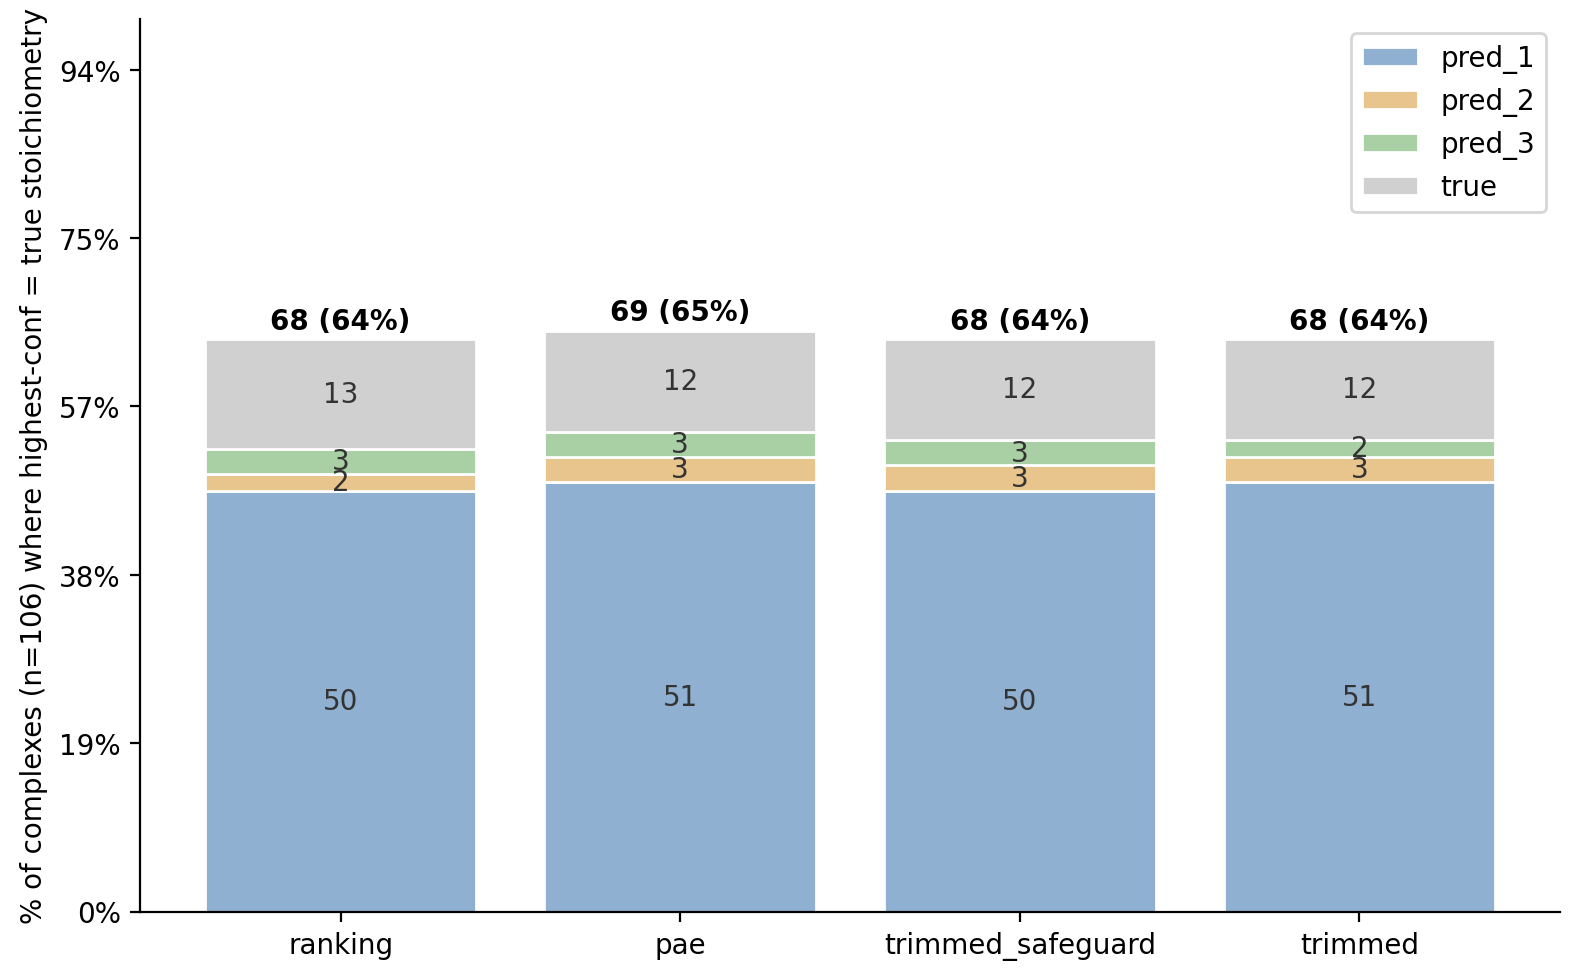

shape: (12, 9)
┌───────────────────┬───────────────────┬──────────┬──────────────────┬───────────────────────┬───────────────────────────┬───────────────────────────┬───────────────┬──────────┐
│ run_a             ┆ run_b             ┆ n_shared ┆ n_correct_shared ┆ pct_correct_if_shared ┆ pct_correct_if_not_shared ┆ pct_correct_run_a_overall ┆ enrichment_pp ┆ fisher_p │
│ ---               ┆ ---               ┆ ---      ┆ ---              ┆ ---                   ┆ ---                       ┆ ---                       ┆ ---           ┆ ---      │
│ str               ┆ str               ┆ i64      ┆ i64              ┆ f64                   ┆ f64                       ┆ f64                       ┆ f64           ┆ f64      │
╞═══════════════════╪═══════════════════╪══════════╪══════════════════╪═══════════════════════╪═══════════════════════════╪═══════════════════════════╪═══════════════╪══════════╡
│ ranking           ┆ pae               ┆ 71       ┆ 56               ┆ 78.873            

In [55]:
# ---------------- bar chart: how often is the highest-confidence output the true one ----------------
correct_counts = {
    (run, source): count
    for run, source, count in (
        highest_confidence_output.filter(pl.col("best_is_true"))
        .group_by("run", "best_source").len().iter_rows()
    )
}
unexpected_sources = {source for _, source in correct_counts} - set(SOURCES)
assert not unexpected_sources, f"unexpected sources: {unexpected_sources}"

fig, ax = plt.subplots(figsize=(8, 5))
bottom = [0] * len(RUN_FOLDERS)
for source in SOURCES:
    values = [correct_counts.get((run, source), 0) for run in RUN_FOLDERS]
    bars = ax.bar(list(RUN_FOLDERS), values, bottom=bottom, label=source, color=SOURCE_COLORS[source], edgecolor="white")
    ax.bar_label(bars, labels=[v or "" for v in values], label_type="center", color="#333333")
    bottom = [b + v for b, v in zip(bottom, values)]
for i, total in enumerate(bottom):
    ax.text(i, total + 0.5, f"{total} ({total / n_complexes:.0%})", ha="center", va="bottom", fontweight="bold")

ax.set_ylim(0, n_complexes)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=n_complexes))
ax.set_ylabel(f"% of complexes (n={n_complexes}) where highest-conf = true stoichiometry")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()



# ---------------- one row per complex: best stoichiometry of every run ----------------
best_stoich_per_complex = kept.select("complex_ac", "true_stoich")
for run in RUN_FOLDERS:
    best_stoich_per_complex = best_stoich_per_complex.join(
        highest_confidence_by_run[run].select("complex_ac", pl.col("best_stoich").alias(f"stoich_{run}")),
        on="complex_ac", how="inner",
    )
assert best_stoich_per_complex.height == n_complexes, "complexes lost while building the wide table"


# ---------------- shared best stoichiometry between runs + enrichment of correctness ----------------
# directed: run_a is the row run. "correct" always means: run_a's best stoichiometry == true stoichiometry
pair_rows = []
for run_a, run_b in itertools.permutations(RUN_FOLDERS, 2):
    is_shared = pl.col(f"stoich_{run_a}") == pl.col(f"stoich_{run_b}")
    is_correct_a = pl.col(f"stoich_{run_a}") == pl.col("true_stoich")
    shared, not_shared = best_stoich_per_complex.filter(is_shared), best_stoich_per_complex.filter(~is_shared)
    assert shared.height > 0 and not_shared.height > 0, f"{run_a} vs {run_b}: all or none of the complexes are shared, no enrichment to compute"

    n_correct_shared = shared.filter(is_correct_a).height
    n_correct_not_shared = not_shared.filter(is_correct_a).height
    accuracy_run_a = best_stoich_per_complex.filter(is_correct_a).height / n_complexes
    _, fisher_p = stats.fisher_exact([
        [n_correct_shared, shared.height - n_correct_shared],
        [n_correct_not_shared, not_shared.height - n_correct_not_shared],
    ])
    pair_rows.append({
        "run_a": run_a, "run_b": run_b,
        "n_shared": shared.height,
        "n_correct_shared": n_correct_shared,
        "pct_correct_if_shared": 100 * n_correct_shared / shared.height,
        "pct_correct_if_not_shared": 100 * n_correct_not_shared / not_shared.height,
        "pct_correct_run_a_overall": 100 * accuracy_run_a,
        "enrichment_pp": 100 * (n_correct_shared / shared.height - accuracy_run_a),
        "fisher_p": fisher_p,
    })
pair_stats = pl.DataFrame(pair_rows)
with pl.Config(tbl_rows=20, tbl_cols=12, tbl_width_chars=200):
    print(pair_stats.with_columns(pl.col(pl.Float64).round(3)))



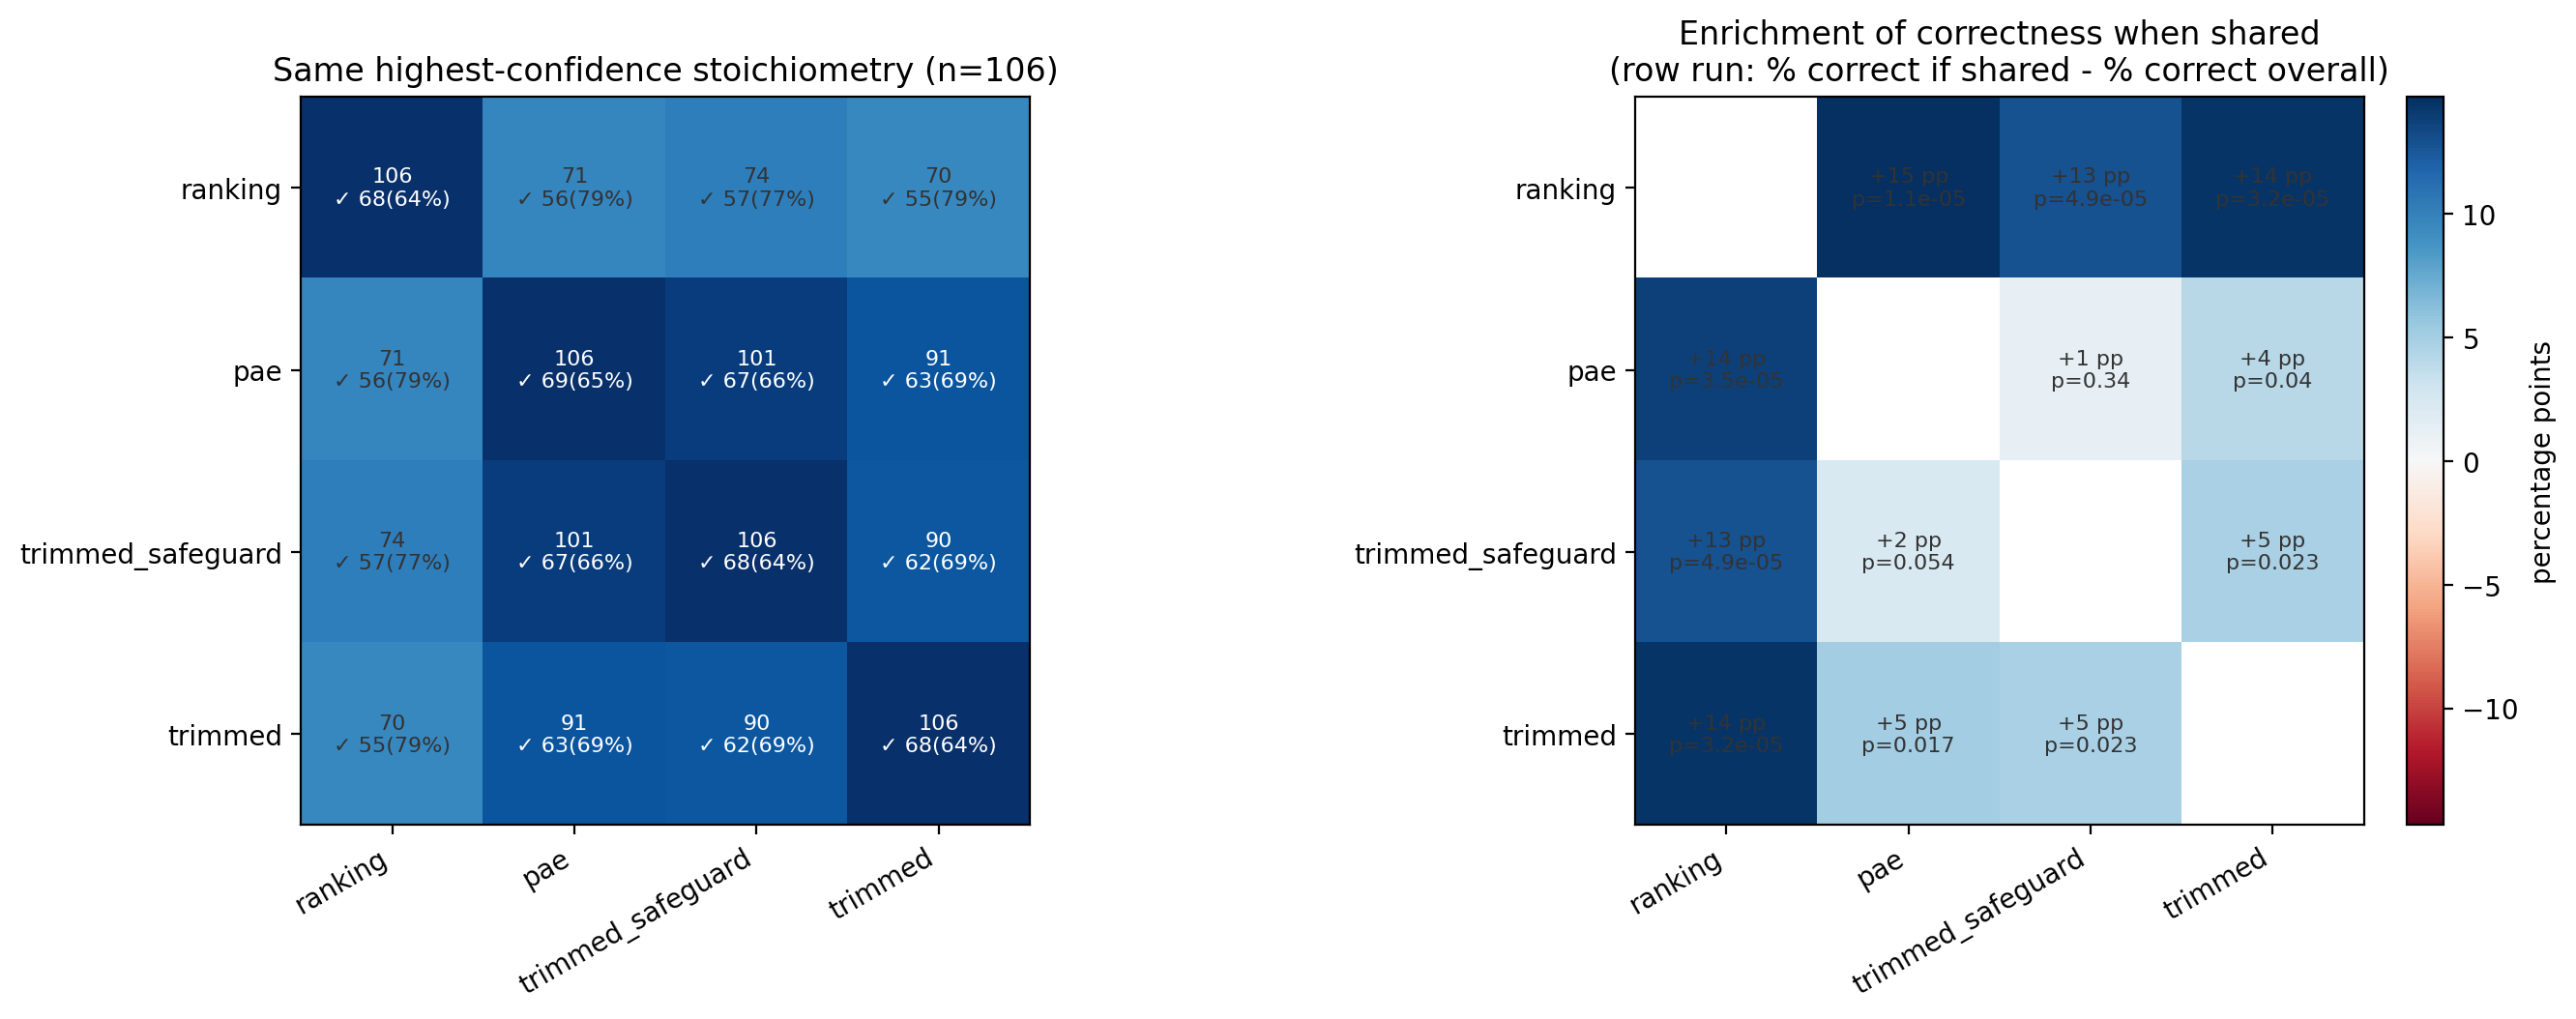

In [56]:
# ---------------- heatmaps: shared count (+ how many correct) and enrichment ----------------
run_names = list(RUN_FOLDERS)
pair_lookup = {(r["run_a"], r["run_b"]): r for r in pair_rows}
diagonal_correct = {run: highest_confidence_by_run[run]["best_is_true"].sum() for run in run_names}

shared_fraction = np.array([[1.0 if a == b else pair_lookup[(a, b)]["n_shared"] / n_complexes for b in run_names] for a in run_names])
enrichment_pp = np.array([[np.nan if a == b else pair_lookup[(a, b)]["enrichment_pp"] for b in run_names] for a in run_names])
max_abs_enrichment = np.nanmax(np.abs(enrichment_pp))

fig, (ax_shared, ax_enrich) = plt.subplots(1, 2, figsize=(14, 5.4))

ax_shared.imshow(shared_fraction, vmin=0, vmax=1, cmap="Blues")
for i, run_a in enumerate(run_names):
    for j, run_b in enumerate(run_names):
        if run_a == run_b:
            n_shared, n_correct = n_complexes, diagonal_correct[run_a]
        else:
            n_shared, n_correct = pair_lookup[(run_a, run_b)]["n_shared"], pair_lookup[(run_a, run_b)]["n_correct_shared"]
        ax_shared.text(j, i, f"{n_shared}\n✓ {n_correct}({n_correct / n_shared:.0%})",
                       ha="center", va="center", fontsize=8,
                       color="white" if shared_fraction[i, j] > 0.75 else "#333333")
ax_shared.set_title(f"Same highest-confidence stoichiometry (n={n_complexes})")

image = ax_enrich.imshow(enrichment_pp, vmin=-max_abs_enrichment, vmax=max_abs_enrichment, cmap="RdBu")
for i, run_a in enumerate(run_names):
    for j, run_b in enumerate(run_names):
        if run_a != run_b:
            row = pair_lookup[(run_a, run_b)]
            ax_enrich.text(j, i, f"{row['enrichment_pp']:+.0f} pp\np={row['fisher_p']:.2g}",
                           ha="center", va="center", fontsize=8, color="#333333")
ax_enrich.set_title("Enrichment of correctness when shared\n(row run: % correct if shared - % correct overall)")
fig.colorbar(image, ax=ax_enrich, fraction=0.046, pad=0.04, label="percentage points")

for ax in (ax_shared, ax_enrich):
    ax.set_xticks(range(len(run_names)), run_names, rotation=30, ha="right")
    ax.set_yticks(range(len(run_names)), run_names)
plt.tight_layout()
plt.show()

how often is which pred correct?

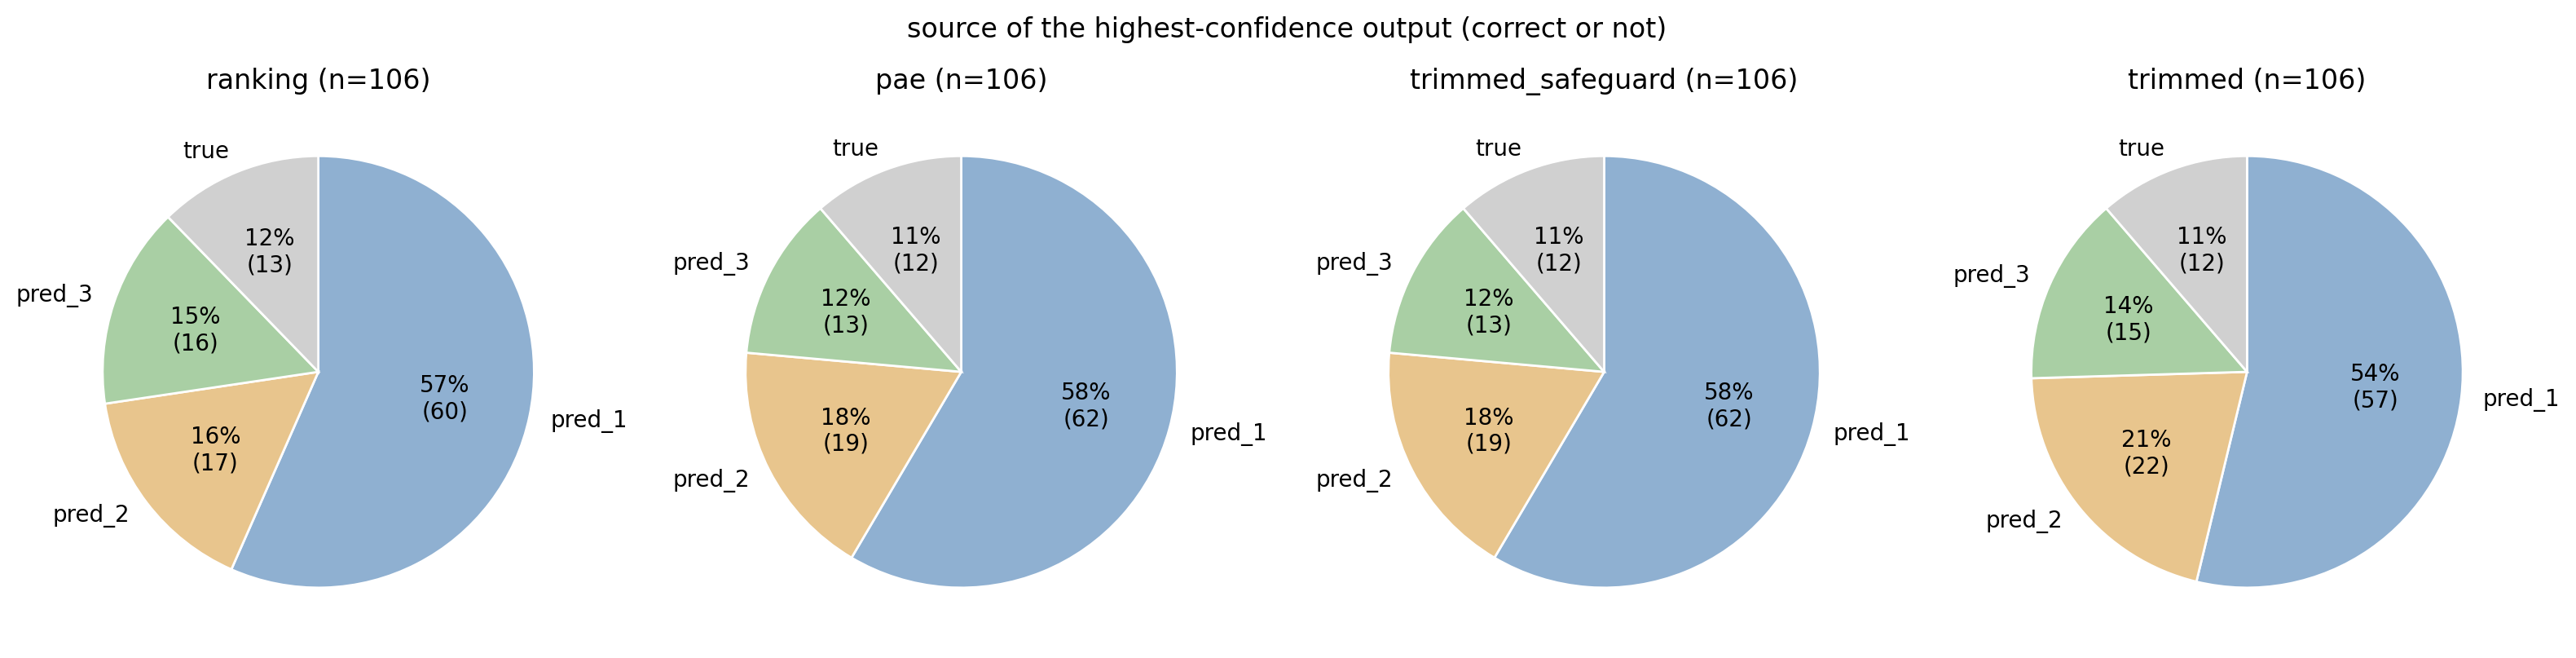

In [57]:
best_source_counts = {
    (run, source): count
    for run, source, count in highest_confidence_output.group_by("run", "best_source").len().iter_rows()
}
assert {source for _, source in best_source_counts} <= set(SOURCES), "unexpected source"

fig, axes = plt.subplots(1, len(RUN_FOLDERS), figsize=(4 * len(RUN_FOLDERS), 4.2))
for ax, run in zip(axes, RUN_FOLDERS):
    sources_of_run = [s for s in SOURCES if (run, s) in best_source_counts]     # sources that never win get no slice
    counts_of_run = [best_source_counts[(run, s)] for s in sources_of_run]
    assert sum(counts_of_run) == n_complexes, f"{run}: pie does not add up to n_complexes"
    ax.pie(counts_of_run, labels=sources_of_run, colors=[SOURCE_COLORS[s] for s in sources_of_run],
           autopct=lambda pct: f"{pct:.0f}%\n({round(pct * n_complexes / 100)})",
           startangle=90, counterclock=False, wedgeprops={"edgecolor": "white"})
    ax.set_title(f"{run} (n={n_complexes})")
fig.suptitle("source of the highest-confidence output (correct or not)")
plt.tight_layout()
plt.show()